# After running ppfx with the EMILES library on the MUSE cube of the central 30 arcseconds here we inspect the results and compare the different libraries used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.io import fits
plots_path ="/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxf_library_comparison_good/"


# EMILES

In [2]:
results_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_emiles_refactored_finer/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.npz'

In [3]:
results_fits_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_emiles_refactored_finer/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits'

In [4]:
results_fits = fits.open(results_fits_path)

## Saved data structure

It has a set of HDUs, the first one is the BINTABLE which has the information about the power binning.  Then it has ImageHDUs containing the maps

In [5]:
results_fits.info()

Filename: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_emiles_refactored_finer/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_emiles.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   ()      
  1  BIN_RESULTS    1 BinTableHDU     39   2180R x 15C   [J, D, D, D, D, D, D, D, D, D, D, D, J, D, D]   
  2  SPAXELS       1 BinTableHDU     35   90000R x 13C   [J, J, D, D, D, D, J, D, D, D, D, D, D]   
  3  BIN_MAP       1 ImageHDU         8   (300, 300)   int32   
  4  VEL_MAP       1 ImageHDU         8   (300, 300)   float32   
  5  SIGMA_MAP     1 ImageHDU         8   (300, 300)   float32   
  6  VELERR_MAP    1 ImageHDU         8   (300, 300)   float32   
  7  SIGERR_MAP    1 ImageHDU         8   (300, 300)   float32   
  8  LOGAGE_MAP    1 ImageHDU         8   (300, 300)   float32   
  9  METAL_MAP     1 ImageHDU         8   (300, 300)   float32   
 10  SIGNAL_MAP    1 ImageHDU         8   (300, 30

## Plot the maps

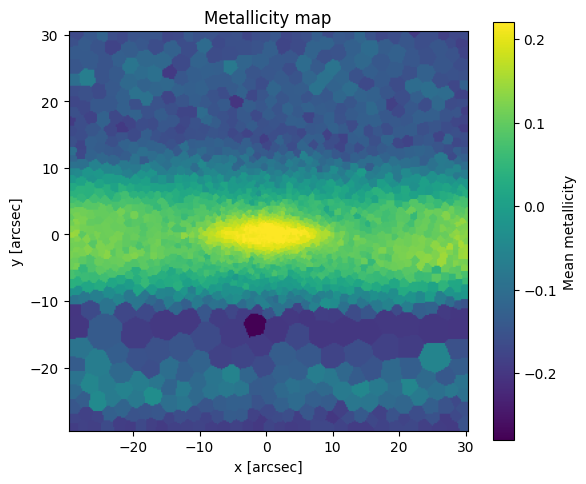

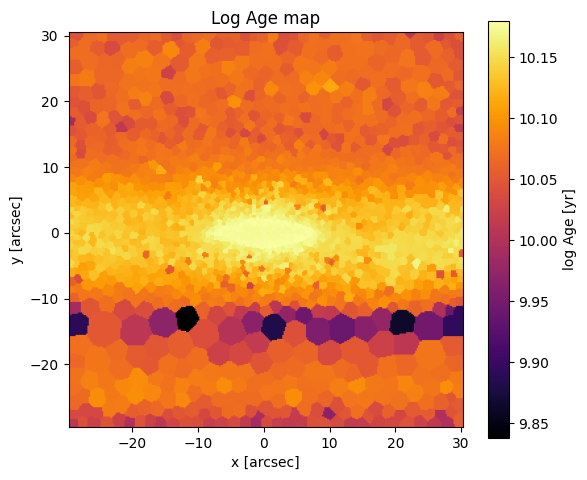

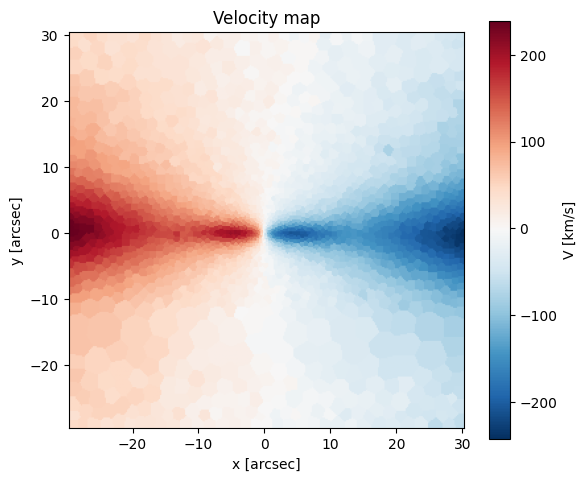

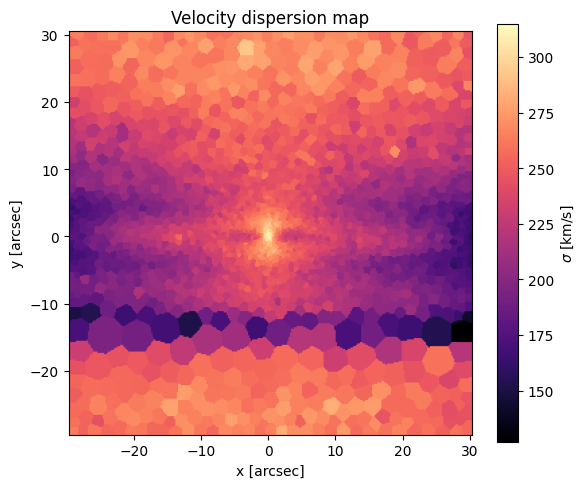

In [6]:

# Read the saved maps
metal_map = results_fits["METAL_MAP"].data
logage_map = results_fits["LOGAGE_MAP"].data
vel_map = results_fits["VEL_MAP"].data
sigma_map = results_fits["SIGMA_MAP"].data

# Get x/y coordinates from the SPAXELS table so the axes are in arcsec
spax = results_fits["SPAXELS"].data
x = spax["X_ARCSEC"]
y = spax["Y_ARCSEC"]

# Estimate image extent from the spaxel coordinates
x_unique = np.unique(np.round(x, 6))
y_unique = np.unique(np.round(y, 6))

dx = np.median(np.diff(x_unique)) if len(x_unique) > 1 else 1.0
dy = np.median(np.diff(y_unique)) if len(y_unique) > 1 else 1.0

extent = [
    x_unique.min() - dx/2, x_unique.max() + dx/2,
    y_unique.min() - dy/2, y_unique.max() + dy/2
]

def plot_map(data, title, cbar_label, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        data,
        origin="lower",
        extent=extent,
        aspect="equal",
        cmap=cmap
    )
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    ax.set_xlabel("x [arcsec]")
    ax.set_ylabel("y [arcsec]")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_map(metal_map, "Metallicity map", "Mean metallicity", cmap="viridis")
plot_map(logage_map, "Log Age map", "log Age [yr]", cmap="inferno")
plot_map(vel_map, "Velocity map", "V [km/s]", cmap="RdBu_r")
plot_map(sigma_map, "Velocity dispersion map", r"$\sigma$ [km/s]", cmap="magma")

## Radial maps

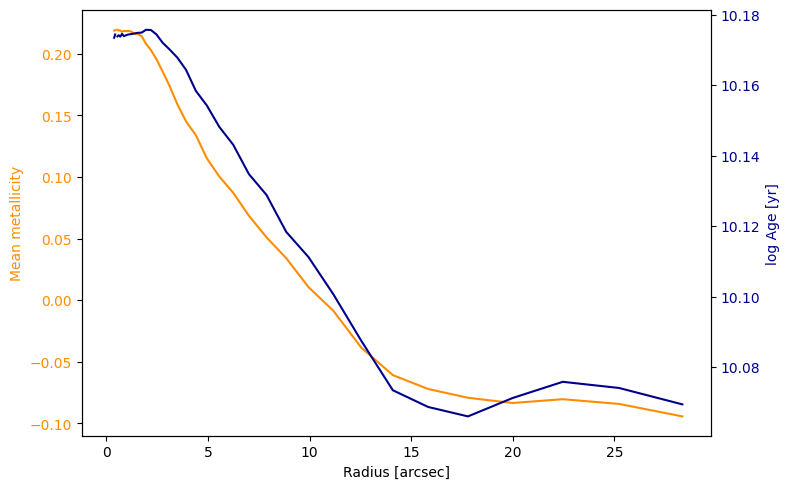

In [7]:
# lets take compute the radial metallicity and age profiles by averaging in annuli
r = np.sqrt(x**2 + y**2) # this is the flattened radius in arcsec
# make it 2D for use in masking the maps
r = r.reshape(metal_map.shape)  # reshape to match the map dimensions

#r_bins = np.arange(0, 29, 1)  # 1 arcsec bins up to 30 arcsec
# make logspaced bins with a higher resolution in the center
r_bins = np.logspace(np.log10(0.1), np.log10(30), num=50)  # 15 bins from 0.5 to 30 arcsec
r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2
metal_radial_profile = np.zeros_like(r_bin_centers)
logage_radial_profile = np.zeros_like(r_bin_centers)

for i in range(len(r_bins) - 1):
    in_bin = (r >= r_bins[i]) & (r < r_bins[i+1])
    if np.sum(in_bin) > 0:
        avg_mg= np.nanmean(metal_map[in_bin])
        metal_radial_profile[i] = avg_mg
        logage_radial_profile[i] = np.nanmean(logage_map[in_bin])
    else:
        metal_radial_profile[i] = np.nan
        logage_radial_profile[i] = np.nan
# Plot the radial profiles
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(r_bin_centers, metal_radial_profile, label="Metallicity", color="darkorange")
ax1.set_xlabel("Radius [arcsec]")
ax1.set_ylabel("Mean metallicity", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax2 = ax1.twinx()
ax2.plot(r_bin_centers, logage_radial_profile, label="Log Age", color="darkblue")
ax2.set_ylabel("log Age [yr]", color="darkblue")
ax2.tick_params(axis="y", labelcolor="darkblue")
fig.tight_layout()
plt.show()

# XSL

In [8]:
results_xsl = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_xsl/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_xsl.fits')

# FSPS

In [9]:
results_fsps = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_fsps/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_fsps.fits')

# Comparison M/H

In [10]:
os.makedirs(plots_path, exist_ok=True)

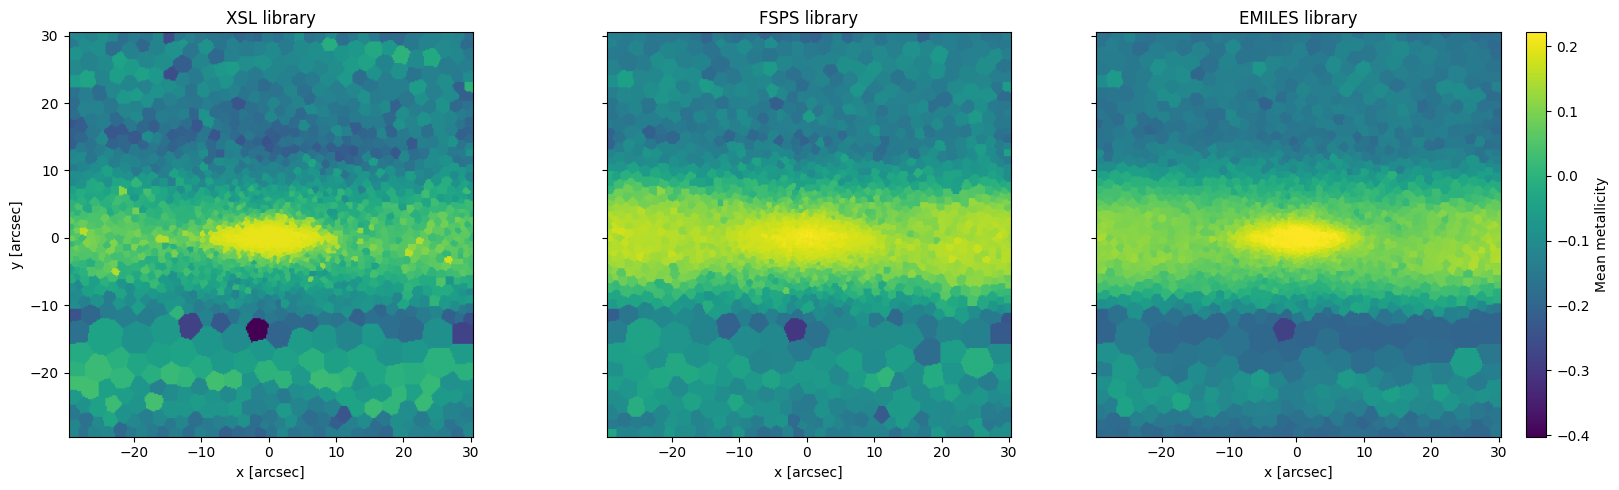

In [11]:
# plot the M/H map for each library side by side with the same color scale
metal_map_xsl = results_xsl["METAL_MAP"].data
metal_map_fsps = results_fsps["METAL_MAP"].data
metal_map_emiles = results_fits["METAL_MAP"].data
# 
vmin = min(np.nanmin(metal_map_xsl), np.nanmin(metal_map_fsps), np.nanmin(metal_map_emiles))
vmax = max(np.nanmax(metal_map_xsl), np.nanmax(metal_map_fsps), np.nanmax(metal_map_emiles))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
axes[0].imshow(metal_map_xsl, origin="lower", extent=extent, aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("XSL library")
axes[0].set_xlabel("x [arcsec]")
axes[0].set_ylabel("y [arcsec]")
axes[1].imshow(metal_map_fsps, origin="lower", extent=extent, aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("FSPS library")
axes[1].set_xlabel("x [arcsec]")
#axes[1].set_ylabel("y [arcsec]")
axes[2].imshow(metal_map_emiles, origin="lower", extent=extent, aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[2].set_title("EMILES library")
axes[2].set_xlabel("x [arcsec]")
#axes[2].set_ylabel("y [arcsec]")
fig.colorbar(plt.cm.ScalarMappable(cmap="viridis", 
                                   norm=plt.Normalize(vmin=vmin, vmax=vmax)),
                                     ax=axes[2], orientation="vertical",
                                       label="Mean metallicity",
                                       )
plt.tight_layout()
plt.savefig(os.path.join(plots_path, "metal_maps.png"), dpi=600)
plt.show()

# Comparison Age

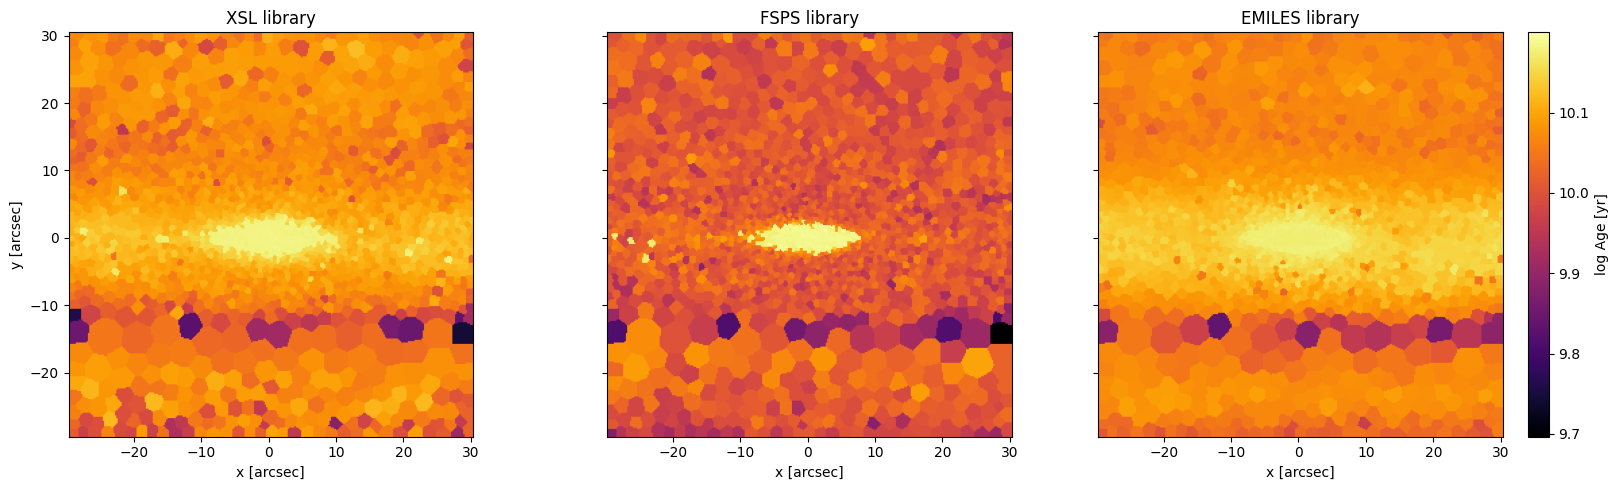

In [12]:
age_map_xsl = results_xsl["LOGAGE_MAP"].data
age_map_fsps = results_fsps["LOGAGE_MAP"].data
age_map_emiles = results_fits["LOGAGE_MAP"].data

vmin = min(np.nanmin(age_map_xsl), np.nanmin(age_map_fsps), np.nanmin(age_map_emiles))
vmax = max(np.nanmax(age_map_xsl), np.nanmax(age_map_fsps), np.nanmax(age_map_emiles))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
axes[0].imshow(age_map_xsl, origin="lower", extent=extent, aspect="equal", cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title("XSL library")
axes[0].set_xlabel("x [arcsec]")
axes[0].set_ylabel("y [arcsec]")
axes[1].imshow(age_map_fsps, origin="lower", extent=extent, aspect="equal", cmap="inferno", vmin=vmin, vmax=vmax)
axes[1].set_title("FSPS library")
axes[1].set_xlabel("x [arcsec]")
axes[2].imshow(age_map_emiles, origin="lower", extent=extent, aspect="equal", cmap="inferno", vmin=vmin, vmax=vmax)
axes[2].set_title("EMILES library")
axes[2].set_xlabel("x [arcsec]")
fig.colorbar(plt.cm.ScalarMappable(cmap="inferno",
                                   norm=plt.Normalize(vmin=vmin, vmax=vmax)),
                                     ax=axes[2], orientation="vertical",
                                       label="log Age [yr]",
                                        )
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'age_maps.png'), dpi=600)
plt.show()

# Radial M/H and Logage

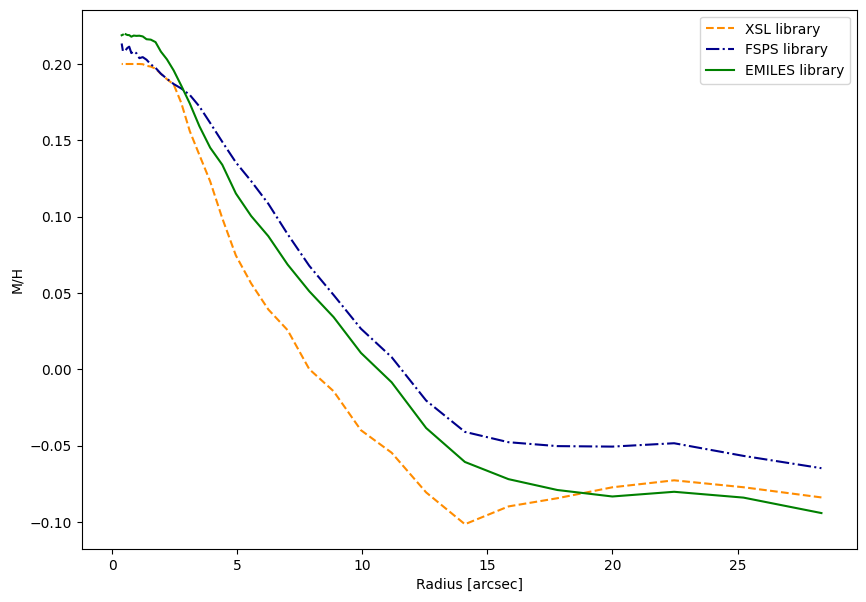

In [13]:
radius = np.sqrt(x**2 + y**2).reshape(metal_map.shape)
# make radial bins
r_bins = np.logspace(np.log10(0.1), np.log10(30), num=50)  # 15 bins from 0.5 to 30 arcsec
r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2
# compute radial profiles for each library
metal_radial_xsl = np.zeros_like(r_bin_centers)
metal_radial_fsps = np.zeros_like(r_bin_centers)
metal_radial_emiles = np.zeros_like(r_bin_centers)

for i in range(len(r_bins) - 1):
    in_bin = (radius >= r_bins[i]) & (radius < r_bins[i+1])
    if np.sum(in_bin) > 0:
        metal_radial_xsl[i] = np.nanmean(metal_map_xsl[in_bin])
        metal_radial_fsps[i] = np.nanmean(metal_map_fsps[in_bin])
        metal_radial_emiles[i] = np.nanmean(metal_map_emiles[in_bin])
    else:
        metal_radial_xsl[i] = np.nan
        metal_radial_fsps[i] = np.nan
        metal_radial_emiles[i] = np.nan
# plot the radial profiles
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(r_bin_centers, metal_radial_xsl, label="XSL library", color="darkorange", linestyle="--")
ax.plot(r_bin_centers, metal_radial_fsps, label="FSPS library", color="darkblue", linestyle='-.')
ax.plot(r_bin_centers, metal_radial_emiles, label="EMILES library", color="green")
ax.set_xlabel("Radius [arcsec]")
ax.set_ylabel("M/H")
plt.legend()
plt.savefig(os.path.join(plots_path, 'metal_radial_profiles.png'), dpi=600)
plt.show()

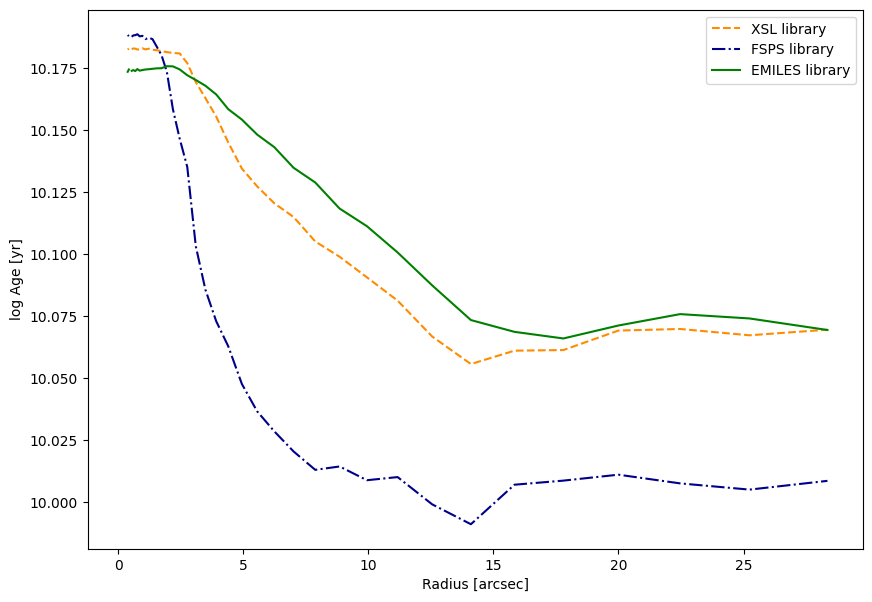

In [14]:
# now with the age
age_radial_xsl = np.zeros_like(r_bin_centers)
age_radial_fsps = np.zeros_like(r_bin_centers)
age_radial_emiles = np.zeros_like(r_bin_centers)

for i in range(len(r_bins) - 1):
    in_bin = (radius >= r_bins[i]) & (radius < r_bins[i+1])
    if np.sum(in_bin) > 0:
        age_radial_xsl[i] = np.nanmean(age_map_xsl[in_bin])
        age_radial_fsps[i] = np.nanmean(age_map_fsps[in_bin])
        age_radial_emiles[i] = np.nanmean(age_map_emiles[in_bin])
    else:
        age_radial_xsl[i] = np.nan
        age_radial_fsps[i] = np.nan
        age_radial_emiles[i] = np.nan
# plot the radial profiles
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(r_bin_centers, age_radial_xsl, label="XSL library", color="darkorange", linestyle="--")
ax.plot(r_bin_centers, age_radial_fsps, label="FSPS library", color="darkblue", linestyle='-.')
ax.plot(r_bin_centers, age_radial_emiles, label="EMILES library", color="green")
ax.set_xlabel("Radius [arcsec]")
ax.set_ylabel("log Age [yr]")
plt.legend()
plt.savefig(os.path.join(plots_path, 'age_radial_profiles.png'), dpi=600)
plt.show()


# Plot age, M/H coloured by weights

In [15]:
results_xsl.info()

Filename: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxfppxf_c30_xsl/c30_DATACUBE_normppxf_skycont_Part1_0000_ppxf_products_xsl.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   ()      
  1  BIN_RESULTS    1 BinTableHDU     39   2180R x 15C   [J, D, D, D, D, D, D, D, D, D, D, D, J, D, D]   
  2  SPAXELS       1 BinTableHDU     35   90000R x 13C   [J, J, D, D, D, D, J, D, D, D, D, D, D]   
  3  BIN_MAP       1 ImageHDU         8   (300, 300)   int32   
  4  VEL_MAP       1 ImageHDU         8   (300, 300)   float32   
  5  SIGMA_MAP     1 ImageHDU         8   (300, 300)   float32   
  6  VELERR_MAP    1 ImageHDU         8   (300, 300)   float32   
  7  SIGERR_MAP    1 ImageHDU         8   (300, 300)   float32   
  8  LOGAGE_MAP    1 ImageHDU         8   (300, 300)   float32   
  9  METAL_MAP     1 ImageHDU         8   (300, 300)   float32   
 10  SIGNAL_MAP    1 ImageHDU         8   (300, 300)   float32   
 11  NO

Weights shape: (26, 8, 2180) (43, 9, 2180) (25, 6, 2180)
Age grid shape: (26, 8) (43, 9) (25, 6)


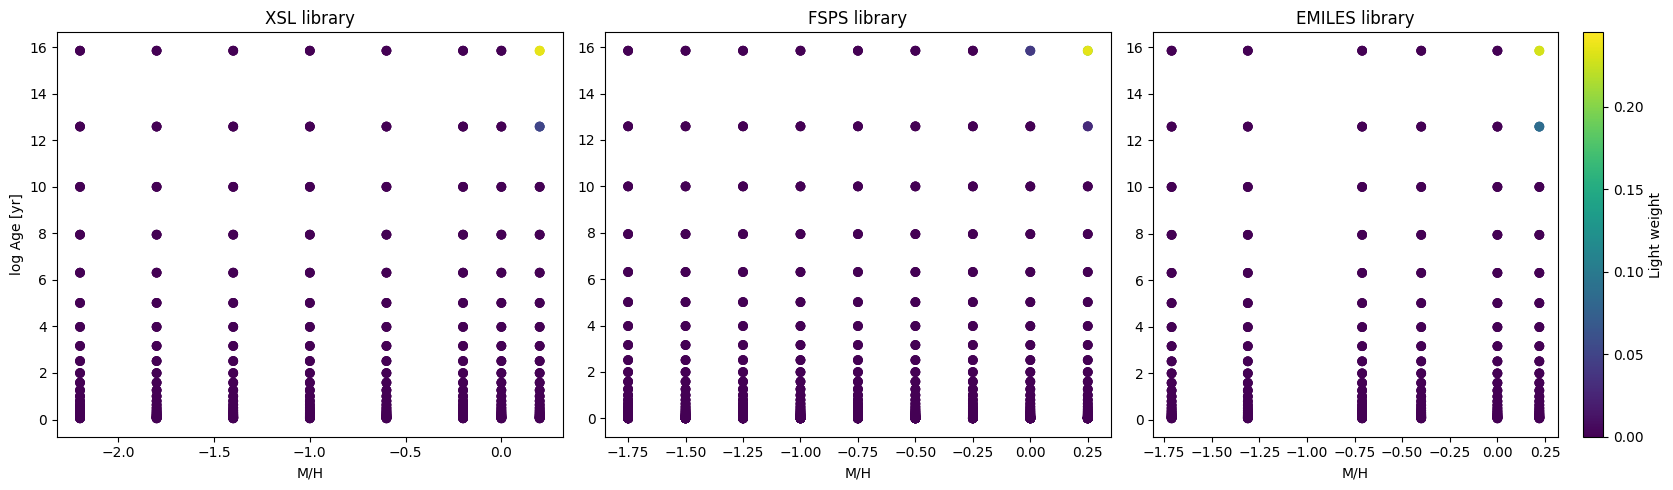

In [16]:
# get the weigths from the fits
weights_xsl = results_xsl["LIGHT_WGT"].data
weights_fsps = results_fsps["LIGHT_WGT"].data
weights_emiles = results_fits["LIGHT_WGT"].data

print("Weights shape:", weights_xsl.shape, weights_fsps.shape, weights_emiles.shape)
# the weights have the same shape as the age and metal grid used, which is also in the fits file
age_grid_xsl = results_xsl["AGE_GRID"].data
metal_grid_xsl = results_xsl["METAL_GRID"].data
age_grid_fsps = results_fsps["AGE_GRID"].data
metal_grid_fsps = results_fsps["METAL_GRID"].data
age_grid_emiles = results_fits["AGE_GRID"].data
metal_grid_emiles = results_fits["METAL_GRID"].data
print("Age grid shape:", age_grid_xsl.shape, age_grid_fsps.shape, age_grid_emiles.shape)
# the third dimension of the weights correspond to the different bins in the fit, which are the same for all fits.
# we can also remap using the weights shape 
# lets plot the 2d histogram of the age-metallicity grid using the mean weight for each bin as the binstatistics.
# but lets do it for the central 3 arcseconds, for this we need to map the bins to spaxels, we can do this using the bin_results
# lets select only the bins that are within 3 arcseconds, we can do this by checking the radius of the spaxels in each bin and selecting the bins that have at least one spaxel with radius < 3 arcsec
bin_results = results_fits["BIN_RESULTS"].data
bin_ids = bin_results["BIN_ID"]
bin_x = bin_results["X_ARCSEC"]
bin_y = bin_results["Y_ARCSEC"]
bin_radius = np.sqrt(bin_x**2 + bin_y**2)
central_bins = bin_ids[bin_radius < 3]
#print("Central bins:", central_bins)
central_weights_xsl = weights_xsl[:, :, central_bins]
central_weights_fsps = weights_fsps[:, :, central_bins]
central_weights_emiles = weights_emiles[:, :, central_bins]


# lets plot the age-metalllicity grid for the first 100 bins for each library, using the weights as the color
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i in range(3):
    im = axes[0].scatter(metal_grid_xsl, age_grid_xsl, c=central_weights_xsl[:, :, i], cmap="viridis", vmin=0, vmax=np.nanmax(central_weights_xsl))
    im = axes[1].scatter(metal_grid_fsps, age_grid_fsps, c=central_weights_fsps[:, :, i], cmap="viridis", vmin=0, vmax=np.nanmax(central_weights_fsps))
    im = axes[2].scatter(metal_grid_emiles, age_grid_emiles, c=central_weights_emiles[:, :, i], cmap="viridis", vmin=0, vmax=np.nanmax(central_weights_emiles))
axes[0].set_title("XSL library")
axes[0].set_xlabel("M/H")
axes[0].set_ylabel("log Age [yr]")
axes[1].set_title("FSPS library")
axes[1].set_xlabel("M/H")
axes[2].set_title("EMILES library")
axes[2].set_xlabel("M/H")
fig.colorbar(im, ax=axes[2], orientation="vertical", label="Light weight")
plt.tight_layout()
plt.show()

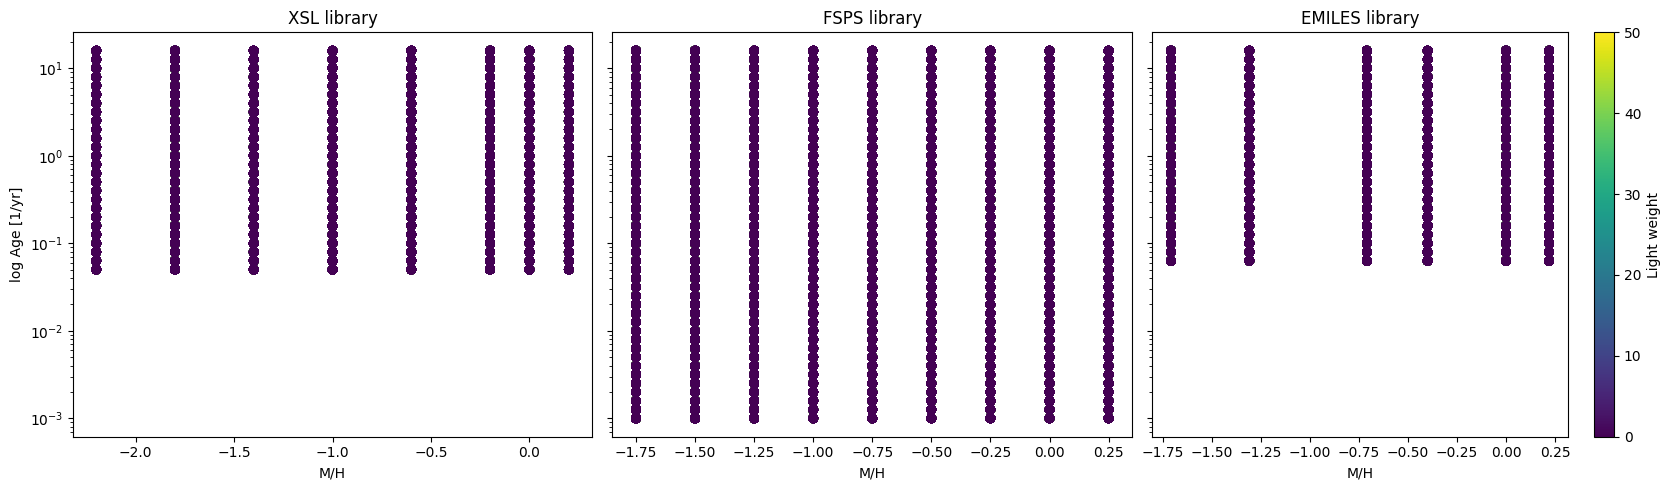

In [17]:
#results_fits['BIN_RESULTS'] # 
# select bins in the central 3 arcseconds
bin_results = results_fits["BIN_RESULTS"].data 
# TTYPE2  = 'X_ARCSEC'                                                            
# TFORM2  = 'D       '                                                            
# TTYPE3  = 'Y_ARCSEC' 
central_bins = bin_results[(bin_results["X_ARCSEC"]**2 + bin_results["Y_ARCSEC"]**2) < 3**2]

# lets get the weights for the central bins and plot the age-metallicity grid for those bins only, for each library
central_weights_xsl = weights_xsl[:, :, central_bins["BIN_ID"]]
central_weights_fsps = weights_fsps[:, :, central_bins["BIN_ID"]]
central_weights_emiles = weights_emiles[:, :, central_bins["BIN_ID"]]
vmin = 20
vmax = 50

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for i in range(central_weights_xsl.shape[2]):
    im = axes[0].scatter(metal_grid_xsl, age_grid_xsl, c=central_weights_xsl[:, :, i], cmap="viridis", vmin=0, vmax=vmax)
    im = axes[1].scatter(metal_grid_fsps, age_grid_fsps, c=central_weights_fsps[:, :, i], cmap="viridis", vmin=0, vmax=vmax)
    im = axes[2].scatter(metal_grid_emiles, age_grid_emiles, c=central_weights_emiles[:, :, i], cmap="viridis", vmin=0, vmax=vmax)
axes[0].set_title("XSL library")
axes[0].set_xlabel("M/H")
axes[0].set_ylabel("log Age [1/yr]")
axes[1].set_title("FSPS library")
axes[1].set_xlabel("M/H")
axes[2].set_title("EMILES library")
axes[2].set_xlabel("M/H")
# make the Y axis logscale
for ax in axes:
    ax.set_yscale("log")
fig.colorbar(im, ax=axes[2], orientation="vertical", label="Light weight")
plt.tight_layout()
plt.show()

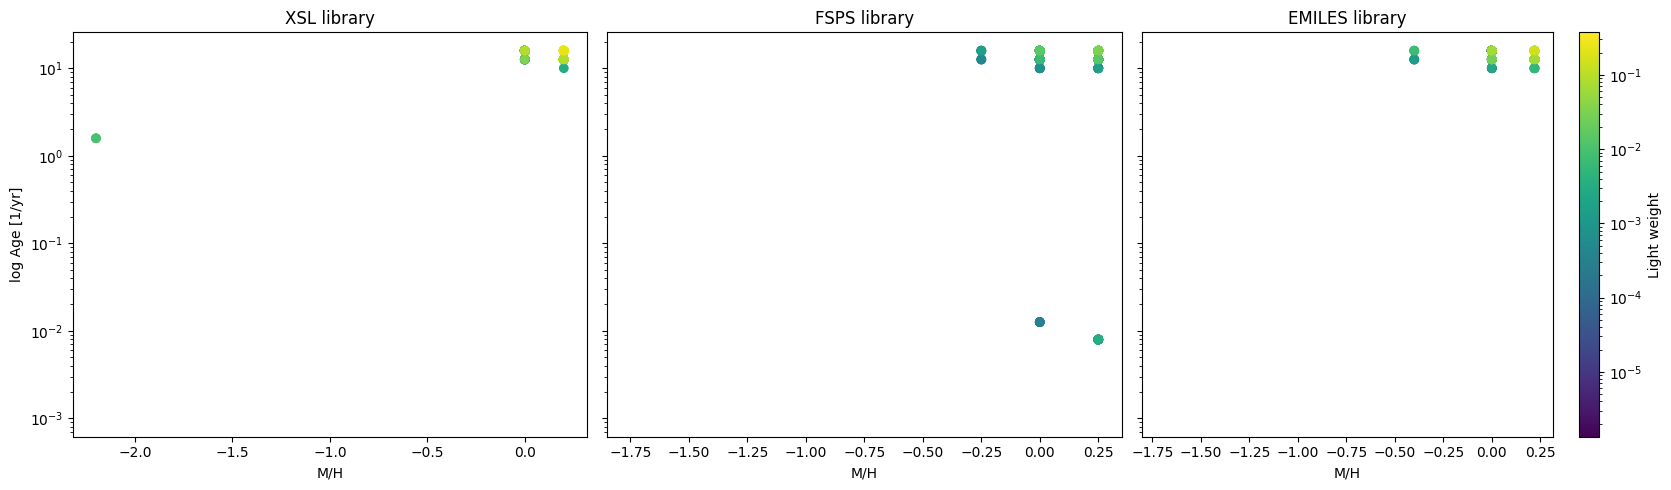

In [18]:
from matplotlib.colors import LogNorm

# Shared color scale across all libraries (ignore zeros for LogNorm)
all_w = np.concatenate([
    central_weights_xsl.ravel(),
    central_weights_fsps.ravel(),
    central_weights_emiles.ravel()
])
all_w_pos = all_w[all_w > 0]

vmin = np.nanmin(all_w_pos)
vmax = np.nanmax(all_w_pos)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for i in range(central_weights_xsl.shape[2]):
    axes[0].scatter(metal_grid_xsl, age_grid_xsl, c=central_weights_xsl[:, :, i], cmap="viridis", norm=norm)
    axes[1].scatter(metal_grid_fsps, age_grid_fsps, c=central_weights_fsps[:, :, i], cmap="viridis", norm=norm)
    im = axes[2].scatter(metal_grid_emiles, age_grid_emiles, c=central_weights_emiles[:, :, i], cmap="viridis", norm=norm)

axes[0].set_title("XSL library")
axes[1].set_title("FSPS library")
axes[2].set_title("EMILES library")

axes[0].set_xlabel("M/H")
axes[1].set_xlabel("M/H")
axes[2].set_xlabel("M/H")
axes[0].set_ylabel("log Age [1/yr]")

for ax in axes:
    ax.set_yscale("log")

# one shared colorbar for all panels
fig.colorbar(im, ax=axes[2], orientation="vertical", label="Light weight")
plt.tight_layout()
plt.show()

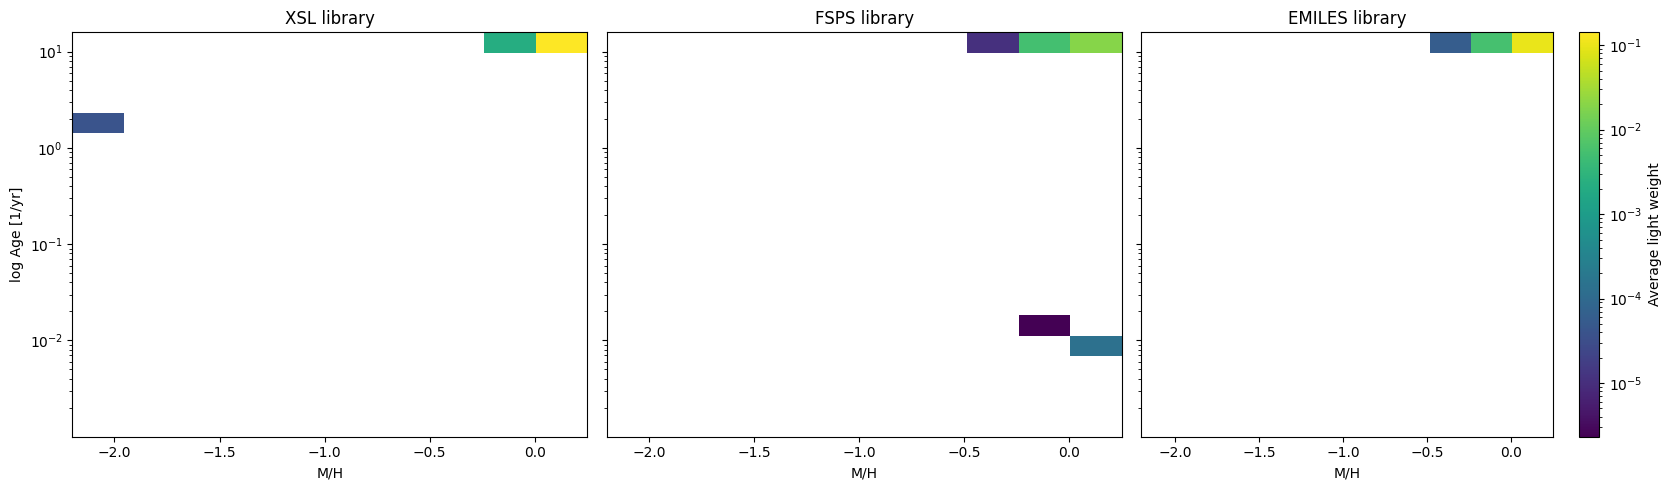

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d

# --- choose bin edges ---
nbins_x = 10
nbins_y = 20

def mean_weight_2dhist(metal_grid, age_grid, weight_cube, xedges=None, yedges=None):
    # repeat the age/metal grid for each slice in the 3rd dimension
    nlib = weight_cube.shape[2]

    x = np.repeat(metal_grid[..., None], nlib, axis=2).ravel()
    y = np.repeat(age_grid[..., None], nlib, axis=2).ravel()
    w = weight_cube.ravel()

    # remove NaNs/infs
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(w)
    x, y, w = x[m], y[m], w[m]

    # if no edges supplied, make them from the data
    if xedges is None:
        xedges = np.linspace(np.nanmin(x), np.nanmax(x), nbins_x + 1)
    if yedges is None:
        # log-spaced bins so they look sensible with a log y-axis
        yedges = np.geomspace(np.nanmin(y[y > 0]), np.nanmax(y), nbins_y + 1)

    H_mean, _, _, _ = binned_statistic_2d(
        x, y, w,
        statistic="mean",
        bins=[xedges, yedges]
    )

    return H_mean.T, xedges, yedges  # transpose for pcolormesh

# --- common bin edges across all libraries ---
x_all = np.concatenate([
    np.repeat(metal_grid_xsl[..., None], central_weights_xsl.shape[2], axis=2).ravel(),
    np.repeat(metal_grid_fsps[..., None], central_weights_fsps.shape[2], axis=2).ravel(),
    np.repeat(metal_grid_emiles[..., None], central_weights_emiles.shape[2], axis=2).ravel()
])

y_all = np.concatenate([
    np.repeat(age_grid_xsl[..., None], central_weights_xsl.shape[2], axis=2).ravel(),
    np.repeat(age_grid_fsps[..., None], central_weights_fsps.shape[2], axis=2).ravel(),
    np.repeat(age_grid_emiles[..., None], central_weights_emiles.shape[2], axis=2).ravel()
])

x_all = x_all[np.isfinite(x_all)]
y_all = y_all[np.isfinite(y_all) & (y_all > 0)]

xedges = np.linspace(np.nanmin(x_all), np.nanmax(x_all), nbins_x + 1)
yedges = np.geomspace(np.nanmin(y_all), np.nanmax(y_all), nbins_y + 1)

# --- compute mean-weight histograms ---
H_xsl, _, _ = mean_weight_2dhist(metal_grid_xsl, age_grid_xsl, central_weights_xsl, xedges, yedges)
H_fsps, _, _ = mean_weight_2dhist(metal_grid_fsps, age_grid_fsps, central_weights_fsps, xedges, yedges)
H_emiles, _, _ = mean_weight_2dhist(metal_grid_emiles, age_grid_emiles, central_weights_emiles, xedges, yedges)

# --- shared color scale based on the binned means ---
all_H = np.concatenate([
    H_xsl.ravel(),
    H_fsps.ravel(),
    H_emiles.ravel()
])

all_H_pos = all_H[np.isfinite(all_H) & (all_H > 0)]
norm = LogNorm(vmin=np.nanmin(all_H_pos), vmax=np.nanmax(all_H_pos))

# mask empty / non-positive bins for LogNorm
H_xsl = np.ma.masked_invalid(H_xsl)
H_xsl = np.ma.masked_less_equal(H_xsl, 0)

H_fsps = np.ma.masked_invalid(H_fsps)
H_fsps = np.ma.masked_less_equal(H_fsps, 0)

H_emiles = np.ma.masked_invalid(H_emiles)
H_emiles = np.ma.masked_less_equal(H_emiles, 0)

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

im0 = axes[0].pcolormesh(xedges, yedges, H_xsl, cmap="viridis", norm=norm, shading="auto")
im1 = axes[1].pcolormesh(xedges, yedges, H_fsps, cmap="viridis", norm=norm, shading="auto")
im2 = axes[2].pcolormesh(xedges, yedges, H_emiles, cmap="viridis", norm=norm, shading="auto")

axes[0].set_title("XSL library")
axes[1].set_title("FSPS library")
axes[2].set_title("EMILES library")

for ax in axes:
    ax.set_xlabel("M/H")
    ax.set_yscale("log")

axes[0].set_ylabel("log Age [1/yr]")

fig.colorbar(im2, ax=axes[2], orientation="vertical", label="Average light weight")
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'age_metallicity_weighted_histograms_central_3arcsec.png'), dpi=600)
plt.show()

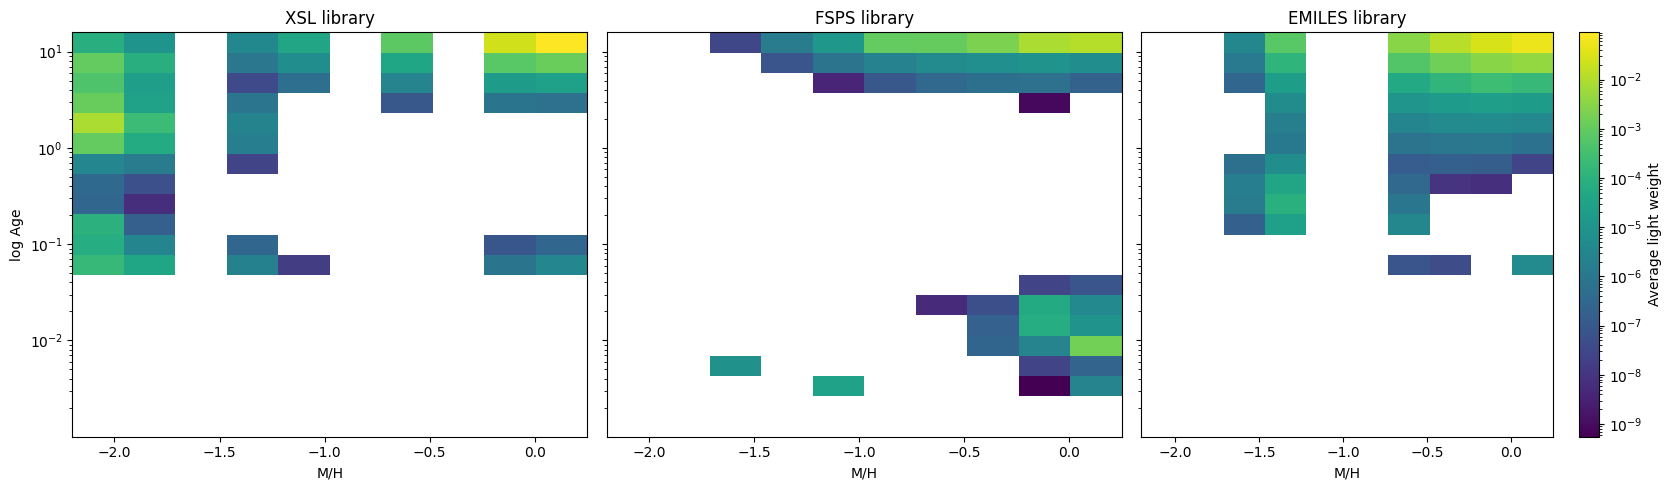

In [20]:
# now for the region outside 6 arcseconds, we can do the same but select bins with radius > 6 arcsec
# now the outer anulus between 6 and 15 arcseconds
outer_bins = bin_ids[(bin_radius >= 6) & (bin_radius < 15)]
outer_weights_xsl = weights_xsl[:, :, outer_bins]
outer_weights_fsps = weights_fsps[:, :, outer_bins]
outer_weights_emiles = weights_emiles[:, :, outer_bins]


# --- common bin edges across all libraries ---
x_all = np.concatenate([
    np.repeat(metal_grid_xsl[..., None], outer_weights_xsl.shape[2], axis=2).ravel(),
    np.repeat(metal_grid_fsps[..., None], outer_weights_fsps.shape[2], axis=2).ravel(),
    np.repeat(metal_grid_emiles[..., None], outer_weights_emiles.shape[2], axis=2).ravel()
])

y_all = np.concatenate([
    np.repeat(age_grid_xsl[..., None], outer_weights_xsl.shape[2], axis=2).ravel(),
    np.repeat(age_grid_fsps[..., None], outer_weights_fsps.shape[2], axis=2).ravel(),
    np.repeat(age_grid_emiles[..., None], outer_weights_emiles.shape[2], axis=2).ravel()
])

x_all = x_all[np.isfinite(x_all)]
y_all = y_all[np.isfinite(y_all) & (y_all > 0)]

xedges = np.linspace(np.nanmin(x_all), np.nanmax(x_all), nbins_x + 1)
yedges = np.geomspace(np.nanmin(y_all), np.nanmax(y_all), nbins_y + 1)

# --- compute mean-weight histograms ---
H_xsl, _, _ = mean_weight_2dhist(metal_grid_xsl, age_grid_xsl, outer_weights_xsl, xedges, yedges)
H_fsps, _, _ = mean_weight_2dhist(metal_grid_fsps, age_grid_fsps, outer_weights_fsps, xedges, yedges)
H_emiles, _, _ = mean_weight_2dhist(metal_grid_emiles, age_grid_emiles, outer_weights_emiles, xedges, yedges)

# --- shared color scale based on the binned means ---
all_H = np.concatenate([
    H_xsl.ravel(),
    H_fsps.ravel(),
    H_emiles.ravel()
])

all_H_pos = all_H[np.isfinite(all_H) & (all_H > 0)]
norm = LogNorm(vmin=np.nanmin(all_H_pos), vmax=np.nanmax(all_H_pos))

# mask empty / non-positive bins for LogNorm
H_xsl = np.ma.masked_invalid(H_xsl)
H_xsl = np.ma.masked_less_equal(H_xsl, 0)

H_fsps = np.ma.masked_invalid(H_fsps)
H_fsps = np.ma.masked_less_equal(H_fsps, 0)

H_emiles = np.ma.masked_invalid(H_emiles)
H_emiles = np.ma.masked_less_equal(H_emiles, 0)

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

im0 = axes[0].pcolormesh(xedges, yedges, H_xsl, cmap="viridis", norm=norm, shading="auto")
im1 = axes[1].pcolormesh(xedges, yedges, H_fsps, cmap="viridis", norm=norm, shading="auto")
im2 = axes[2].pcolormesh(xedges, yedges, H_emiles, cmap="viridis", norm=norm, shading="auto")

axes[0].set_title("XSL library")
axes[1].set_title("FSPS library")
axes[2].set_title("EMILES library")

for ax in axes:
    ax.set_xlabel("M/H")
    ax.set_yscale("log")

axes[0].set_ylabel("log Age")

fig.colorbar(im2, ax=axes[2], orientation="vertical", label="Average light weight")
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'age_metallicity_weighted_histograms_outer_6-15arcsec.png'), dpi=600)
plt.show()

# Check anulii around the center

In [21]:
# compute the mean metallicity and age in the central 1 arcsec
r = np.sqrt(x**2 + y**2).reshape(metal_map.shape)
central_mask = r < 5.0
central_metallicity = np.nanmean(metal_map[central_mask])
central_logage = np.nanmean(logage_map[central_mask])
print(f"Central metallicity (r < 5 arcsec): {central_metallicity:.3f}")
print(f"Central log age (r < 5 arcsec): {central_logage:.3f}")

Central metallicity (r < 5 arcsec): 0.165
Central log age (r < 5 arcsec): 10.167


In [22]:
# compute the mean metallicity and age in the outer 10-30 arcsec
outer_mask = (r >= 10.0) & (r < 30.0)
outer_metallicity = np.nanmean(metal_map[outer_mask])
outer_logage = np.nanmean(logage_map[outer_mask])
print(f"Outer metallicity (10 < r < 30 arcsec): {outer_metallicity:.3f}")
print(f"Outer log age (10 < r < 30 arcsec): {outer_logage:.3f}")


Outer metallicity (10 < r < 30 arcsec): -0.077
Outer log age (10 < r < 30 arcsec): 10.074


## PPXF for the central aperture and anulii fits

In [23]:
from ppxf.ppxf import ppxf, robust_sigma
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from powerbin import PowerBin
from plotbin.display_bins import display_bins

class read_data_cube:
    def __init__(self, filename, lam_range, redshift):
        """Read data cube, de-redshift, log rebin and compute coordinates of each spaxel."""

        self.read_fits_file(filename)

        # Only use the specified rest-frame wavelength range
        wave = self.wave/(1 + redshift)      # de-redshift the spectrum
        w = (wave > lam_range[0]) & (wave < lam_range[1])
        wave = wave[w]
        cube = self.cube[w, ...]
        cubevar = self.cubevar[w, ...]

        signal = np.nanmedian(cube, 0)
        noise = np.sqrt(np.nanmedian(cubevar, 0))

        # Create coordinates centred on the brightest spaxel
        jm = np.argmax(signal)
        row, col = map(np.ravel, np.indices(cube.shape[-2:]))
        x = (col - col[jm])*self.pixsize
        y = (row - row[jm])*self.pixsize

        # Transform cube into 2-dim array of spectra
        npix = cube.shape[0]
        spectra = cube.reshape(npix, -1)        # create array of spectra [npix, nx*ny]
        variance = cubevar.reshape(npix, -1)    # create array of variance [npix, nx*ny]

        c = 299792.458  # speed of light in km/s
        velscale = np.min(c*np.diff(np.log(wave)))  # Preserve smallest velocity step
        lam_range_temp = [np.min(wave), np.max(wave)]
        print(f"Velocity scale of the data: {velscale:.2f} km/s per pixel")
        spectra, ln_lam_gal, velscale = util.log_rebin(lam_range_temp, spectra, velscale=velscale)

        # Coordinates and spectra only for spaxels with enough signal
        self.spectra = spectra
        self.variance = variance
        self.x = x
        self.y = y
        self.signal = signal.ravel()
        self.noise = noise.ravel()

        self.col = col + 1   # start counting from 1
        self.row = row + 1
        self.velscale = velscale
        self.ln_lam_gal = ln_lam_gal
        self.fwhm_gal = self.fwhm_gal/(1 + redshift)

###############################################################################

    def read_fits_file(self, filename):
        """
        Read MUSE cube, noise, wavelength, spectral FWHM and pixel size.

        It must return the cube and cuberr as (npix, nx, ny) and wave as (npix,)

        IMPORTANT: This is not a general function! Its details depend on the
        way the data were stored in the FITS file and the available keywords in
        the FITS header. One may have to adapt the function to properly read
        the FITS file under analysis.
        """
        cube, head = fits.getdata(filename, header=True)

        # Only use the specified rest-frame wavelength range
        wave = head['CRVAL3'] + head['CD3_3']*np.arange(cube.shape[0])

        self.cube = cube
        self.cubevar = cube  # This file contains no uncertainties: assume Poissonian noise
        self.wave = wave
        self.fwhm_gal = 2.62  # Median FWHM = 2.62Å. Range: 2.51--2.88 (ESO instrument manual).
        self.pixsize = abs(head["CD1_1"])*3600    # 0.2"

In [24]:
# load the cube to get the wavelength array
cube_fits_path = '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MUSE/c30_cubes/c30_DATACUBE_normppxf_skycont_Part1_0000.fits'
lam_range_temp = [4750.0, 7409]   # Focus on optical region in MUSE
redshift = 0.003633               # redshift estimate from NED
sn_min = 0.0
cube_orig = read_data_cube(cube_fits_path, lam_range=lam_range_temp, redshift=redshift)


Velocity scale of the data: 50.41 km/s per pixel


KeyboardInterrupt: 

In [ ]:
# load the npz file to check the saved arrays
data_fits_an = np.load("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MUSE/c30_results/anulii/ppxf_central_annulus_results.npz")

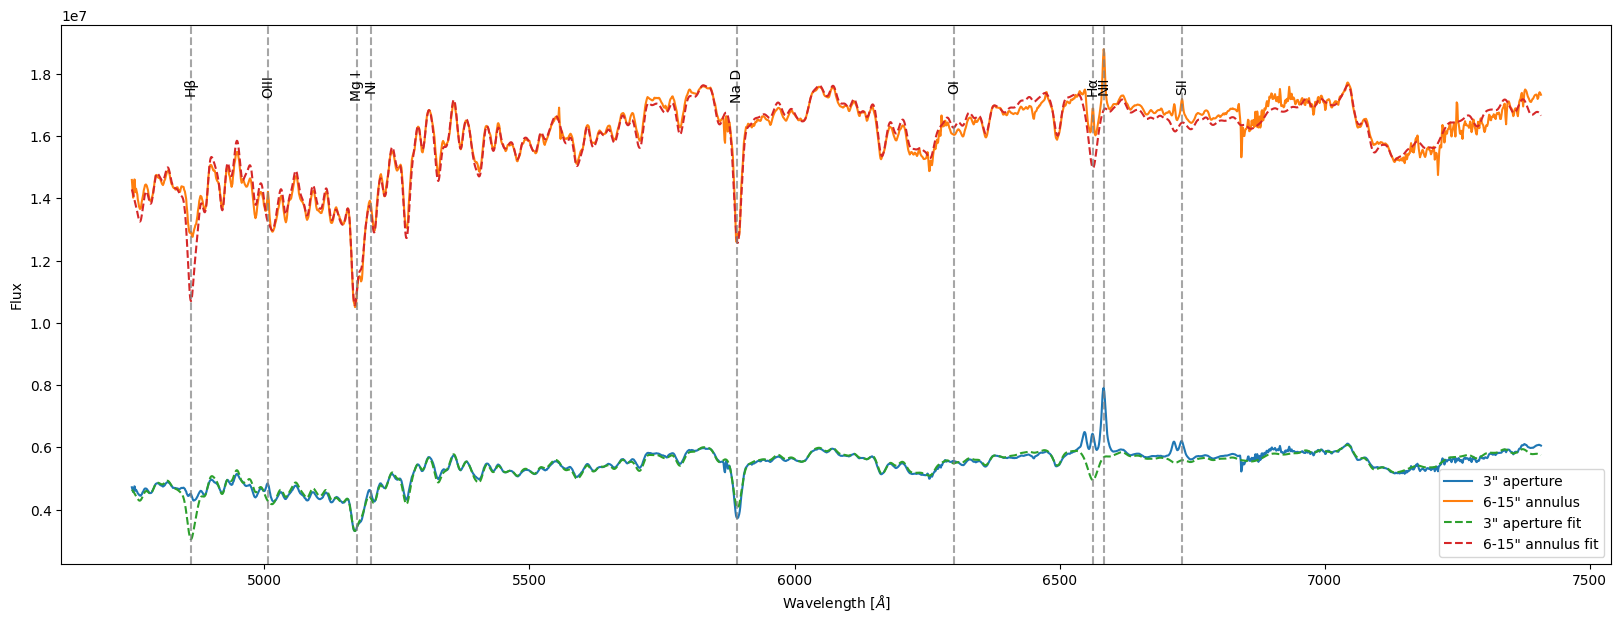

In [ ]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], data_fits_an['binned_spectra'], label = [r'3" aperture', r'6-15" annulus'])
# plot the best fit
ax.plot(data_fits_an['lam_gal'], data_fits_an['binned_bestfit'], label = [r'3" aperture fit', r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
#       NI added by manuel based on https://articles.adsabs.harvard.edu/pdf/1996A%26A...306L..45G
#                     -----[OII]-----    Hdelta   Hgamma   Hbeta   -----[OIII]-----   [OI]    -----[NII]-----   Halpha   -----[SII]-----  -----[NI]doublet-----

lines_ref = np.array([3726.03, 3728.82, 4101.76, 4340.47, 4861.33, 4958.92, 5006.84, 6300.30, 6548.03, 6583.41, 6562.80, 6716.47, 6730.85, 5197.80, 5200.40])
    
important_lines = {
    #"OII": lines_ref[0],  # [OII] 3726.03
    #"OII": lines_ref[1],  # [OII] 3728.82
    #"Hδ": lines_ref[2],   # Hdelta 4101.76
    #"Hγ": lines_ref[3],   # Hgamma 4340.47
    "Hβ": lines_ref[4],   # Hbeta 4861.33
    "OIII": lines_ref[5], # [OIII] 4958.92
    "OIII": lines_ref[6], # [OIII] 5006.84
    "OI": lines_ref[7],   # [OI] 6300.30
    "NII": lines_ref[8],  # [NII] 6548.03
    "NII": lines_ref[9],  # [NII] 6583.41
    "Hα": lines_ref[10],  # Halpha 6562.80
    "SII": lines_ref[11], # [SII] 6716.47
    "SII": lines_ref[12], # [SII] 6730.85
    "NI": lines_ref[13], # NI doublet 5197.80
    "NI": lines_ref[14], # NI doublet 5200.40
    "Na D": 5892.0,
    "Mg I": 5175.0
    # "Hβ": 4861.33, 
    # "[O III]": 5006.84,
    # "Hα": 6562.79,
    # #"[N II]": 6583.45,
    # #"TiO": 6200.0,
    # "Na D": 5892.0,
    # "Mg I": 5175.0,
    # "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel(r"Wavelength $[\AA]$")
ax.set_ylabel("Flux")
ax.legend()
#ax.set_xlim(4750, 7400)
plt.savefig(os.path.join(plots_path, 'spectra_fit_comparison.png'), bbox_inches='tight', dpi=600)
plt.show()


In [ ]:
data_fits_an['binned_spectra'][:,0]

array([4722249.4855957 , 4674673.15506769, 4614277.10009766, ...,
       6081238.60310061, 6071976.65610741, 6059963.90541111],
      shape=(2644,))

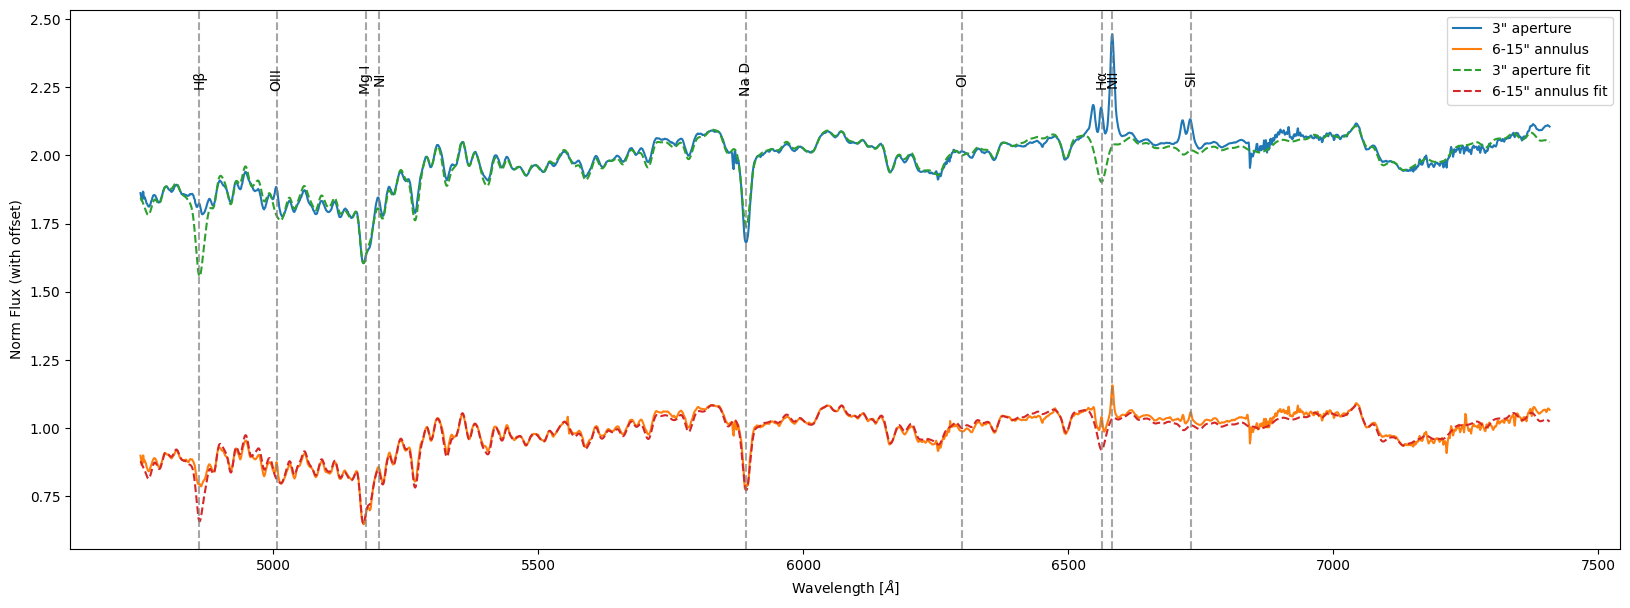

In [ ]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_spectra'][:,0]/np.nanmedian(data_fits_an['binned_spectra'][:,0]) + 1,
          label = [r'3" aperture'])
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_spectra'][:,1]/np.nanmedian(data_fits_an['binned_spectra'][:,1]),
           label = [r'6-15" annulus'])

# plot the best fit
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_bestfit'][:,0]/np.nanmedian(data_fits_an['binned_bestfit'][:,0]) + 1,
          label = [r'3" aperture fit'], linestyle='--')
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_bestfit'][:,1]/np.nanmedian(data_fits_an['binned_bestfit'][:,1]),
           label = [r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
#       NI added by manuel based on https://articles.adsabs.harvard.edu/pdf/1996A%26A...306L..45G
#                     -----[OII]-----    Hdelta   Hgamma   Hbeta   -----[OIII]-----   [OI]    -----[NII]-----   Halpha   -----[SII]-----  -----[NI]doublet-----

lines_ref = np.array([3726.03, 3728.82, 4101.76, 4340.47, 4861.33, 4958.92, 5006.84, 6300.30, 6548.03, 6583.41, 6562.80, 6716.47, 6730.85, 5197.80, 5200.40])
    
important_lines = {
    #"OII": lines_ref[0],  # [OII] 3726.03
    #"OII": lines_ref[1],  # [OII] 3728.82
    #"Hδ": lines_ref[2],   # Hdelta 4101.76
    #"Hγ": lines_ref[3],   # Hgamma 4340.47
    "Hβ": lines_ref[4],   # Hbeta 4861.33
    "OIII": lines_ref[5], # [OIII] 4958.92
    "OIII": lines_ref[6], # [OIII] 5006.84
    "OI": lines_ref[7],   # [OI] 6300.30
    "NII": lines_ref[8],  # [NII] 6548.03
    "NII": lines_ref[9],  # [NII] 6583.41
    "Hα": lines_ref[10],  # Halpha 6562.80
    "SII": lines_ref[11], # [SII] 6716.47
    "SII": lines_ref[12], # [SII] 6730.85
    "NI": lines_ref[13], # NI doublet 5197.80
    "NI": lines_ref[14], # NI doublet 5200.40
    "Na D": 5892.0,
    "Mg I": 5175.0
    # "Hβ": 4861.33, 
    # "[O III]": 5006.84,
    # "Hα": 6562.79,
    # #"[N II]": 6583.45,
    # #"TiO": 6200.0,
    # "Na D": 5892.0,
    # "Mg I": 5175.0,
    # "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel(r"Wavelength $[\AA]$")
ax.set_ylabel("Norm Flux (with offset)")
ax.legend()
#ax.set_xlim(4750, 7400)
plt.savefig(os.path.join(plots_path, 'spectra_fit_comparison_norm_offset.png'), bbox_inches='tight', dpi=600)
plt.show()


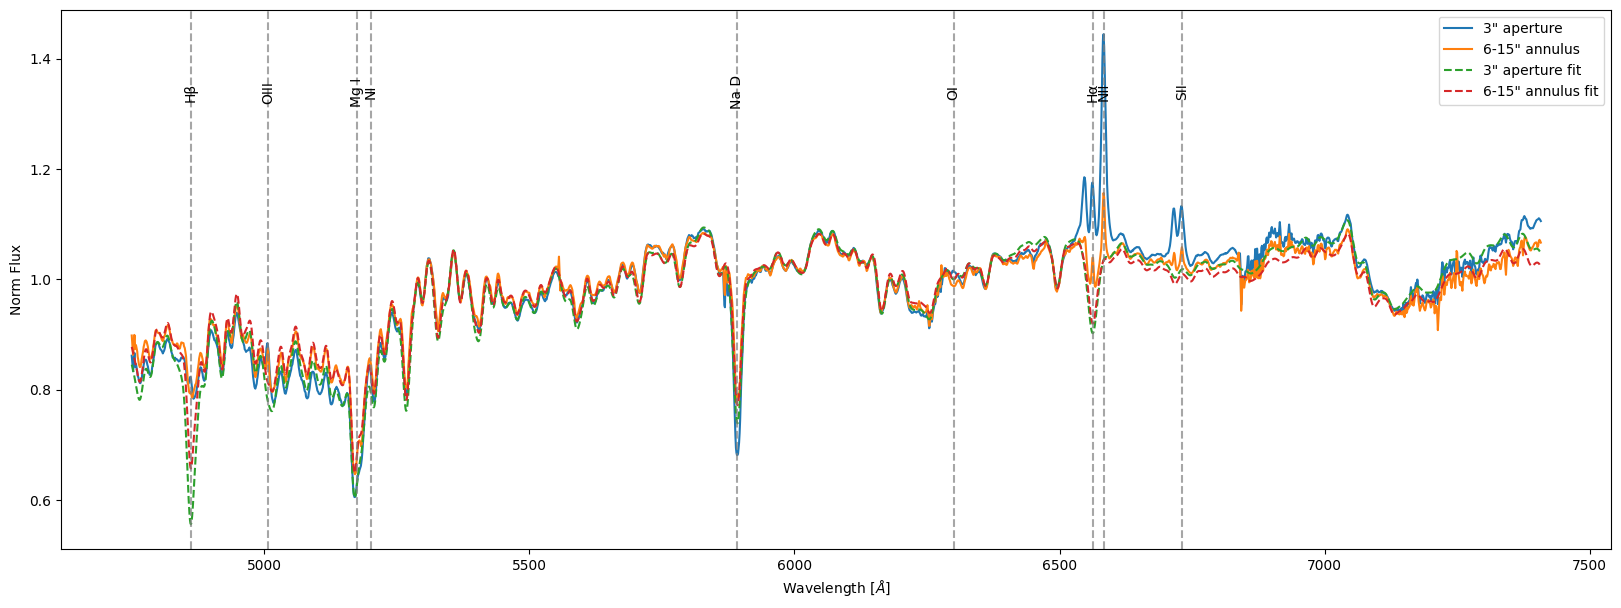

In [ ]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_spectra'][:,0]/np.nanmedian(data_fits_an['binned_spectra'][:,0]),
          label = [r'3" aperture'])
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_spectra'][:,1]/np.nanmedian(data_fits_an['binned_spectra'][:,1]),
           label = [r'6-15" annulus'])

# plot the best fit
ax.plot(data_fits_an['lam_gal'], 
        data_fits_an['binned_bestfit'][:,0]/np.nanmedian(data_fits_an['binned_bestfit'][:,0]),
          label = [r'3" aperture fit'], linestyle='--')
ax.plot(data_fits_an['lam_gal'],
         data_fits_an['binned_bestfit'][:,1]/np.nanmedian(data_fits_an['binned_bestfit'][:,1]),
           label = [r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
#       NI added by manuel based on https://articles.adsabs.harvard.edu/pdf/1996A%26A...306L..45G
#                     -----[OII]-----    Hdelta   Hgamma   Hbeta   -----[OIII]-----   [OI]    -----[NII]-----   Halpha   -----[SII]-----  -----[NI]doublet-----

lines_ref = np.array([3726.03, 3728.82, 4101.76, 4340.47, 4861.33, 4958.92, 5006.84, 6300.30, 6548.03, 6583.41, 6562.80, 6716.47, 6730.85, 5197.80, 5200.40])
    
important_lines = {
    #"OII": lines_ref[0],  # [OII] 3726.03
    #"OII": lines_ref[1],  # [OII] 3728.82
    #"Hδ": lines_ref[2],   # Hdelta 4101.76
    #"Hγ": lines_ref[3],   # Hgamma 4340.47
    "Hβ": lines_ref[4],   # Hbeta 4861.33
    "OIII": lines_ref[5], # [OIII] 4958.92
    "OIII": lines_ref[6], # [OIII] 5006.84
    "OI": lines_ref[7],   # [OI] 6300.30
    "NII": lines_ref[8],  # [NII] 6548.03
    "NII": lines_ref[9],  # [NII] 6583.41
    "Hα": lines_ref[10],  # Halpha 6562.80
    "SII": lines_ref[11], # [SII] 6716.47
    "SII": lines_ref[12], # [SII] 6730.85
    "NI": lines_ref[13], # NI doublet 5197.80
    "NI": lines_ref[14], # NI doublet 5200.40
    "Na D": 5892.0,
    "Mg I": 5175.0
    # "Hβ": 4861.33, 
    # "[O III]": 5006.84,
    # "Hα": 6562.79,
    # #"[N II]": 6583.45,
    # #"TiO": 6200.0,
    # "Na D": 5892.0,
    # "Mg I": 5175.0,
    # "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel(r"Wavelength $[\AA]$")
ax.set_ylabel("Norm Flux")
ax.legend()
#ax.set_xlim(4750, 7400)
plt.savefig(os.path.join(plots_path, 'spectra_fit_comparison_norm_ontop.png'), bbox_inches='tight', dpi=600)
plt.show()


<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_62503/761078162.py:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  ax.set_xlabel("Wavelength $[\AA]$")


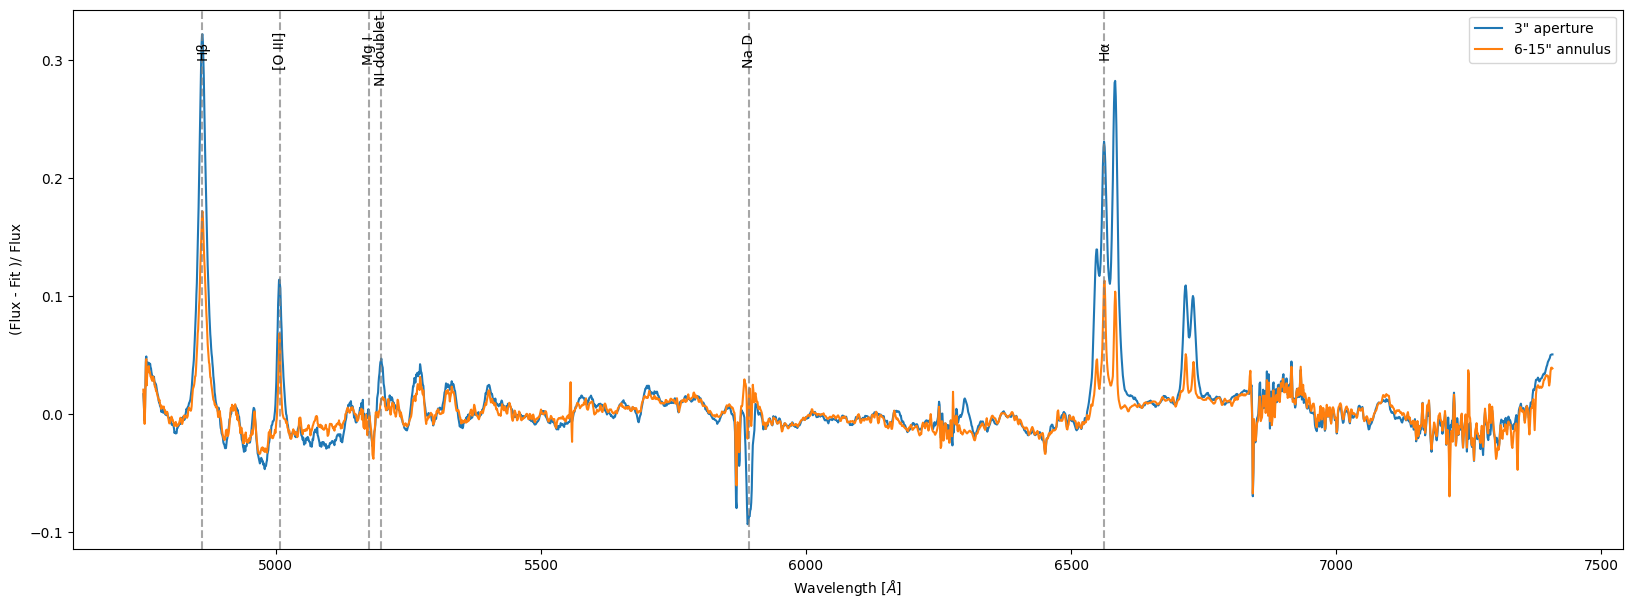

In [ ]:
# plot the spectra and best fit for both
fig, ax = plt.subplots(figsize=(20, 7))
# plot the data
ax.plot(data_fits_an['lam_gal'], (data_fits_an['binned_spectra'] - data_fits_an['binned_bestfit'])/data_fits_an['binned_spectra'], label = [r'3" aperture', r'6-15" annulus'])
# plot the best fit
#ax.plot(data_fits_an['lam_gal'], data_fits_an['binned_bestfit'], label = [r'3" aperture fit', r'6-15" annulus fit'], linestyle='--')

# label some important lines for a galaxy, such as Hbeta, OIII, Halpha, NII, and TiO bands
important_lines = {
    "Hβ": 4861.33,
    "[O III]": 5006.84,
    "Hα": 6562.79,
    #"[N II]": 6583.45,
    #"TiO": 6200.0,
    "Na D": 5892.0,
    "Mg I": 5175.0,
    "NI doublet": 5199.0
}
for line_name, line_wave in important_lines.items():
    ax.axvline(line_wave, color="gray", linestyle="--", alpha=0.7)
    ax.text(line_wave, ax.get_ylim()[1]*0.9, line_name, rotation=90, verticalalignment='center', horizontalalignment='center', fontsize=10)

ax.set_xlabel("Wavelength $[\AA]$")
ax.set_ylabel("(Flux - Fit )/ Flux")
ax.legend()
plt.savefig("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Plots/ppxf_c30_1/spectra_fit_residuals.pdf", bbox_inches='tight')
plt.show()


# Check regularized emiles

In [ ]:
# load the fits file with the output of the ppxf fits for the central annulus
an_test_res = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_results/anulus_test/c30_DATACUBE_normppxf_skycont_Part1_0000_two_aperture_regularized_emiles.fits')

In [ ]:
an_test_res.info()

Filename: /Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_results/anulus_test/c30_DATACUBE_normppxf_skycont_Part1_0000_two_aperture_regularized_emiles.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  APERTURE_RESULTS    1 BinTableHDU     35   2R x 13C   [13A, D, D, J, D, D, D, D, D, D, D, D, D]   
  2  APERTURE_MAP    1 ImageHDU         8   (300, 300)   int32   
  3  LAMBDA_GAL    1 ImageHDU         7   (2644,)   float32   
  4  SPECTRA       1 ImageHDU         8   (2, 2644)   float32   
  5  NOISE         1 ImageHDU         8   (2, 2644)   float32   
  6  BESTFIT       1 ImageHDU         8   (2, 2644)   float32   
  7  GAS_BESTFIT    1 ImageHDU         8   (2, 2644)   float32   
  8  STELLAR_BESTFIT    1 ImageHDU         8   (2, 20182)   float32   
  9  OPT_TEMPLATE    1 ImageHDU         8   (2, 20182)   float32   
 10  LIGHT_WGT     1 ImageHDU         9   (2, 6, 25)   float32   
 11  WGT_SHAPE     

In [ ]:
# lets plot the age-metallicity grid for the central annulus, using the weights from the ppxf fit with the emiles library
# take the columns from the header
print(an_test_res[1].header['TTYPE1'], an_test_res[1].header['TTYPE2'], an_test_res[1].header['TTYPE3'], an_test_res[1].header['TTYPE4'], an_test_res[1].header['TTYPE5'], an_test_res[1].header['TTYPE6'], an_test_res[1].header['TTYPE7'], an_test_res[1].header['TTYPE8'], an_test_res[1].header['TTYPE9'], an_test_res[1].header['TTYPE10'], an_test_res[1].header['TTYPE11'], an_test_res[1].header['TTYPE12'], an_test_res[1].header['TTYPE13'])
print(an_test_res[1].data)

LABEL RMIN_ARC RMAX_ARC N_SPAX SN_BIN CHI2 REGUL V_STARS SIGMA_STARS V_GAS SIGMA_GAS LOGAGE_YR MEAN_METAL
[('central_rlt5',  0.,  5.,  1941, 105.81953457, 11924.99394875, 16335.58777765, -12.46454234, 293.09472711,  -12.46454234,   80., 9.3710524 , -0.38199121)
 ('annulus_10_20', 10., 20., 23572, 145.22459064, 20808.51654116, 13223.24031154,   2.32282045, 250.04691773, 2002.32282045, 1000., 9.51480885, -0.32022556)]


In [ ]:
an_test_res[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  105 / length of dimension 1                          
NAXIS2  =                    2 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   13 / number of table fields                         
TTYPE1  = 'LABEL   '                                                            
TFORM1  = '13A     '                                                            
TTYPE2  = 'RMIN_ARC'                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'RMAX_ARC'        